In [10]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

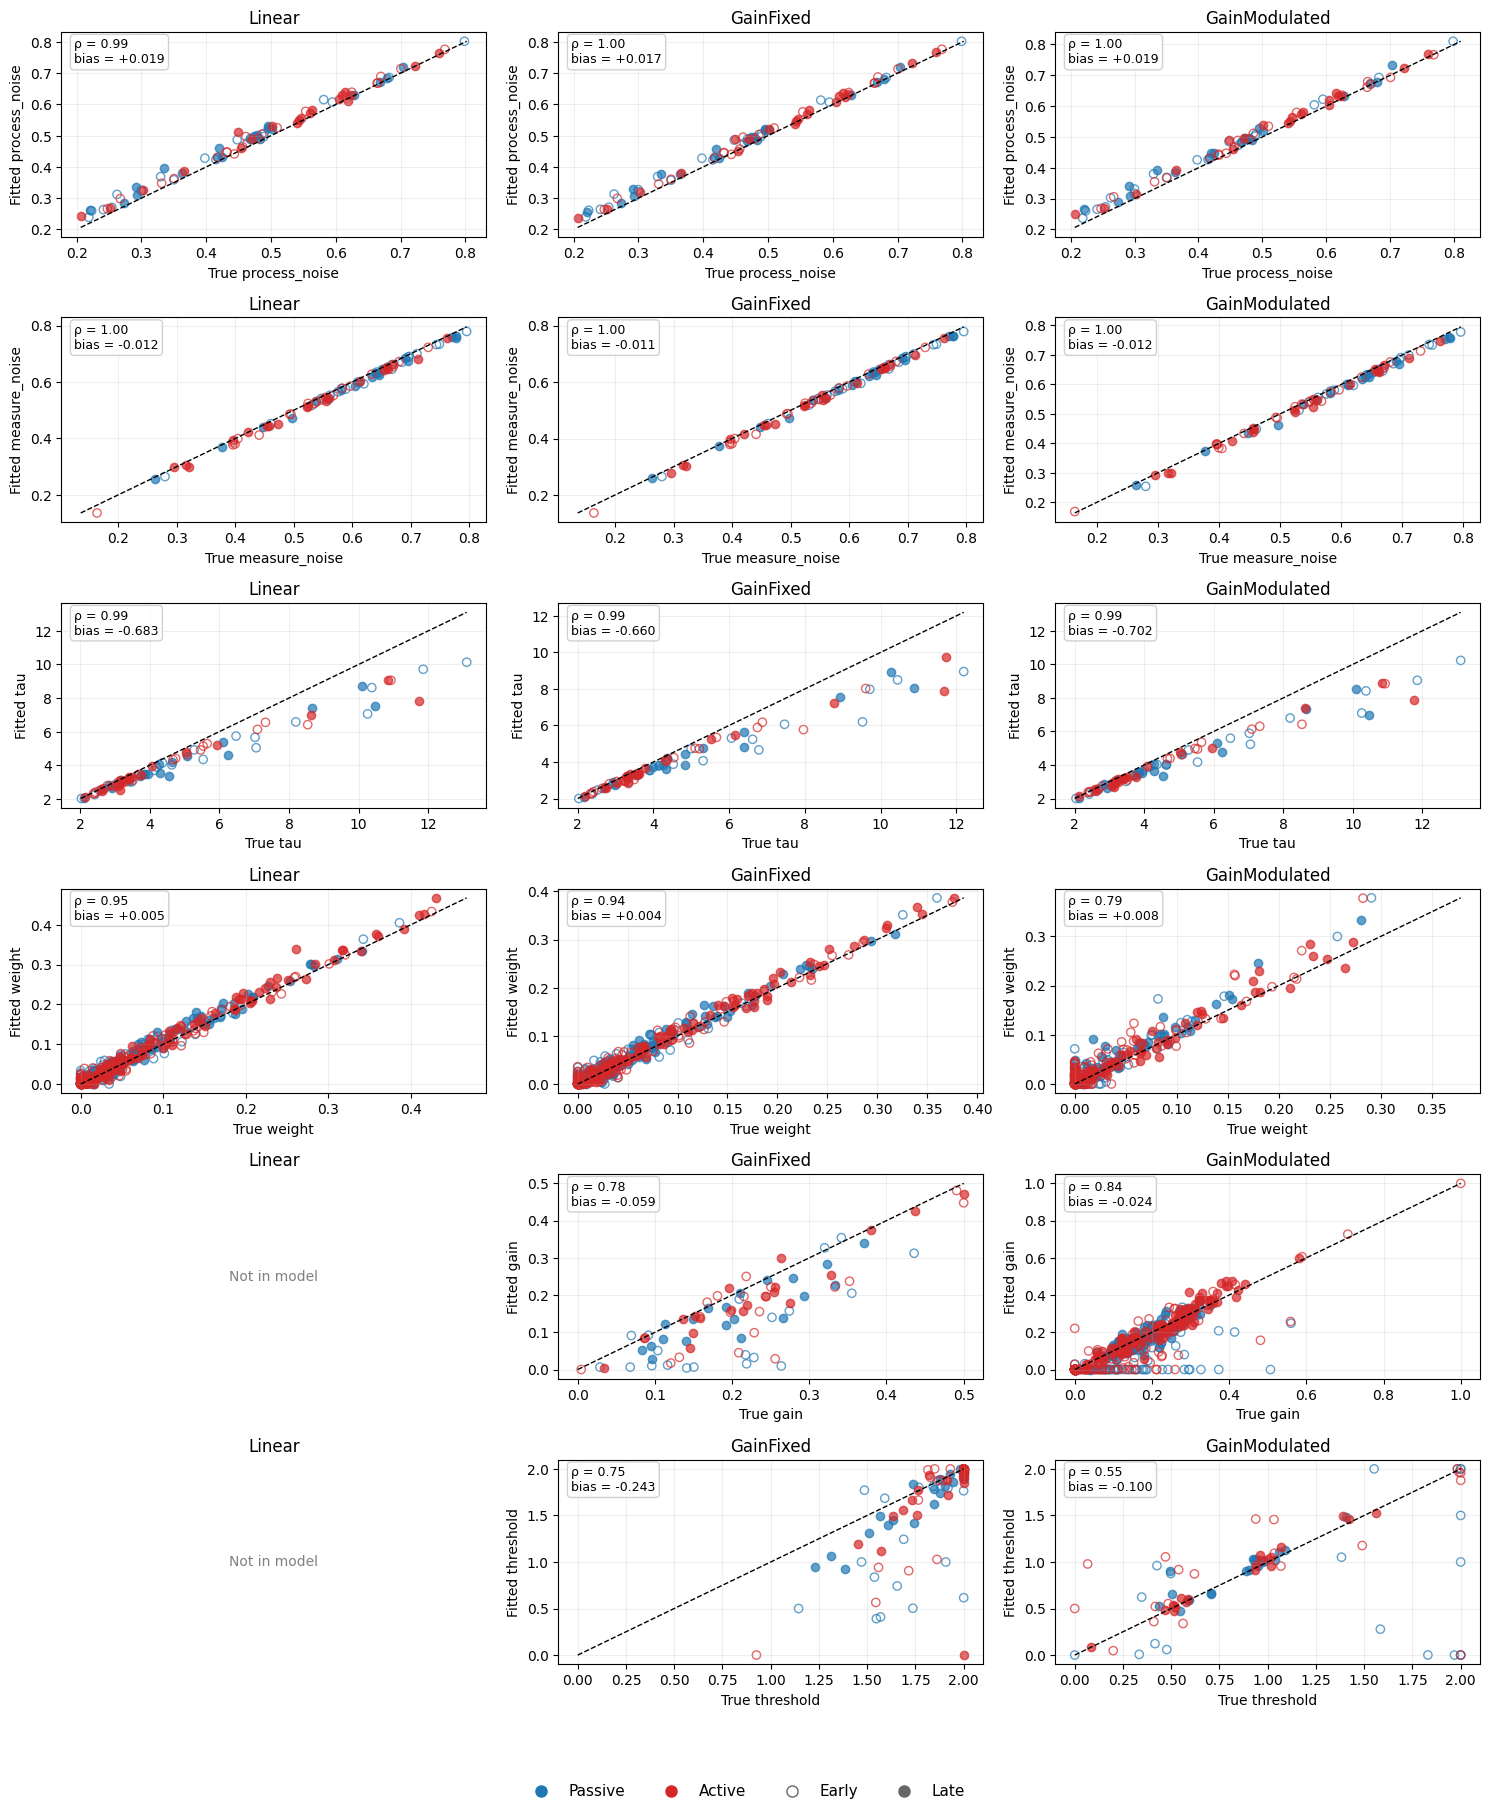

In [22]:
from matplotlib.lines import Line2D
from scipy.stats import spearmanr


models = {
    'Linear': (lead.model.StratifiedLinear, 'LinearModel'),
    'GainFixed': (lead.model.StratifiedNonLinear1, 'GainFixedModel'),
    'GainModulated': (lead.model.StratifiedGainModulation, 'GainModulatedModel'),
}

parameters = ['process_noise', 'measure_noise', 'tau', 'weight', 'gain', 'threshold']

task_colors = {'Passive': '#1f77b4', 'Active': '#d62728'}
periods = ['early', 'late']

conditions = [
    ('Passive', 'late', task_colors['Passive']),
    ('Passive', 'early', task_colors['Passive']),
    ('Active', 'early', task_colors['Active']),
    ('Active', 'late', task_colors['Active']),
]

n_participants = 20


def load_model(model_class, name, path):
    kwargs = dict(tau=10, process_noise=0.1, measure_noise=0.1)
    if name != 'Linear':
        kwargs.update(threshold=1, sharpness=5)
    if name == 'GainFixed':
        kwargs['gain'] = 0.1
    model = model_class(**kwargs)
    model.load_params(path)
    return model


def extract(model, name, param):
    if param == 'weight':
        return [getattr(model, f'w{i}') for i in range(1, 7)]
    if param == 'gain':
        if name == 'GainFixed':
            return [model.gain]
        if name == 'GainModulated':
            return [getattr(model, f'g{i}') for i in range(1, 7)]
        return []
    if not hasattr(model, param):
        return []
    return [getattr(model, param)]


data = {
    name: {param: {(task, period): ([], []) for task, period, _ in conditions} for param in parameters}
    for name in models
}

for name, (model_class, file_name) in models.items():
    for task, period, _ in conditions:
        folder = Path('ParameterRecovery') / f'{task}_{period}' / f'From_{name}'
        for part in range(n_participants):
            true_path = folder / f'TrueModel_part{part}_params'
            fitted_path = folder / f'{file_name}_part{part}_params'
            if not true_path.exists() or not fitted_path.exists():
                continue
            true_model = load_model(model_class, name, true_path)
            fitted_model = load_model(model_class, name, fitted_path)
            for param in parameters:
                true_list, fitted_list = data[name][param][(task, period)]
                true_list.extend(extract(true_model, name, param))
                fitted_list.extend(extract(fitted_model, name, param))

fig, axes = plt.subplots(len(parameters), len(models), figsize=(15, 18))

for row_idx, param in enumerate(parameters):
    for ax, name in zip(axes[row_idx], models):
        all_true, all_fitted = [], []

        for task, period, color in conditions:
            true_arr = np.asarray(data[name][param][(task, period)][0], dtype=float)
            fitted_arr = np.asarray(data[name][param][(task, period)][1], dtype=float)
            valid = np.isfinite(true_arr) & np.isfinite(fitted_arr)
            if valid.any():
                ax.scatter(
                    true_arr[valid],
                    fitted_arr[valid],
                    marker='o',
                    facecolors='none' if period == 'early' else color,
                    edgecolors=color,
                    alpha=0.7,
                )
                all_true.extend(true_arr[valid])
                all_fitted.extend(fitted_arr[valid])

        ax.set_title(name)

        if not all_true:
            ax.text(0.5, 0.5, 'Not in model', ha='center', va='center', transform=ax.transAxes, color='0.5')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            continue

        all_true = np.asarray(all_true)
        all_fitted = np.asarray(all_fitted)

        lo = min(all_true.min(), all_fitted.min())
        hi = max(all_true.max(), all_fitted.max())
        if hi > lo:
            ax.plot([lo, hi], [lo, hi], 'k--', lw=1)

        rho = spearmanr(all_true, all_fitted)[0] if len(all_true) > 2 else np.nan
        bias = np.mean(all_fitted - all_true)
        ax.text(
            0.03, 0.97,
            f'ρ = {rho:.2f}\nbias = {bias:+.3f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='0.8', alpha=0.9),
        )

        ax.set_xlabel(f'True {param}')
        ax.set_ylabel(f'Fitted {param}')
        ax.grid(alpha=0.2)

task_handles = [
    Line2D([0], [0], marker='o', linestyle='', markersize=8,
           markerfacecolor=color, markeredgecolor=color, label=task)
    for task, color in task_colors.items()
]
period_handles = [
    Line2D([0], [0], marker='o', linestyle='', markersize=8,
           markerfacecolor='none' if period == 'early' else '0.4', markeredgecolor='0.4',
           label=period.capitalize())
    for period in periods
]

fig.legend(
    handles=task_handles + period_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
    frameon=False,
    fontsize=11,
)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

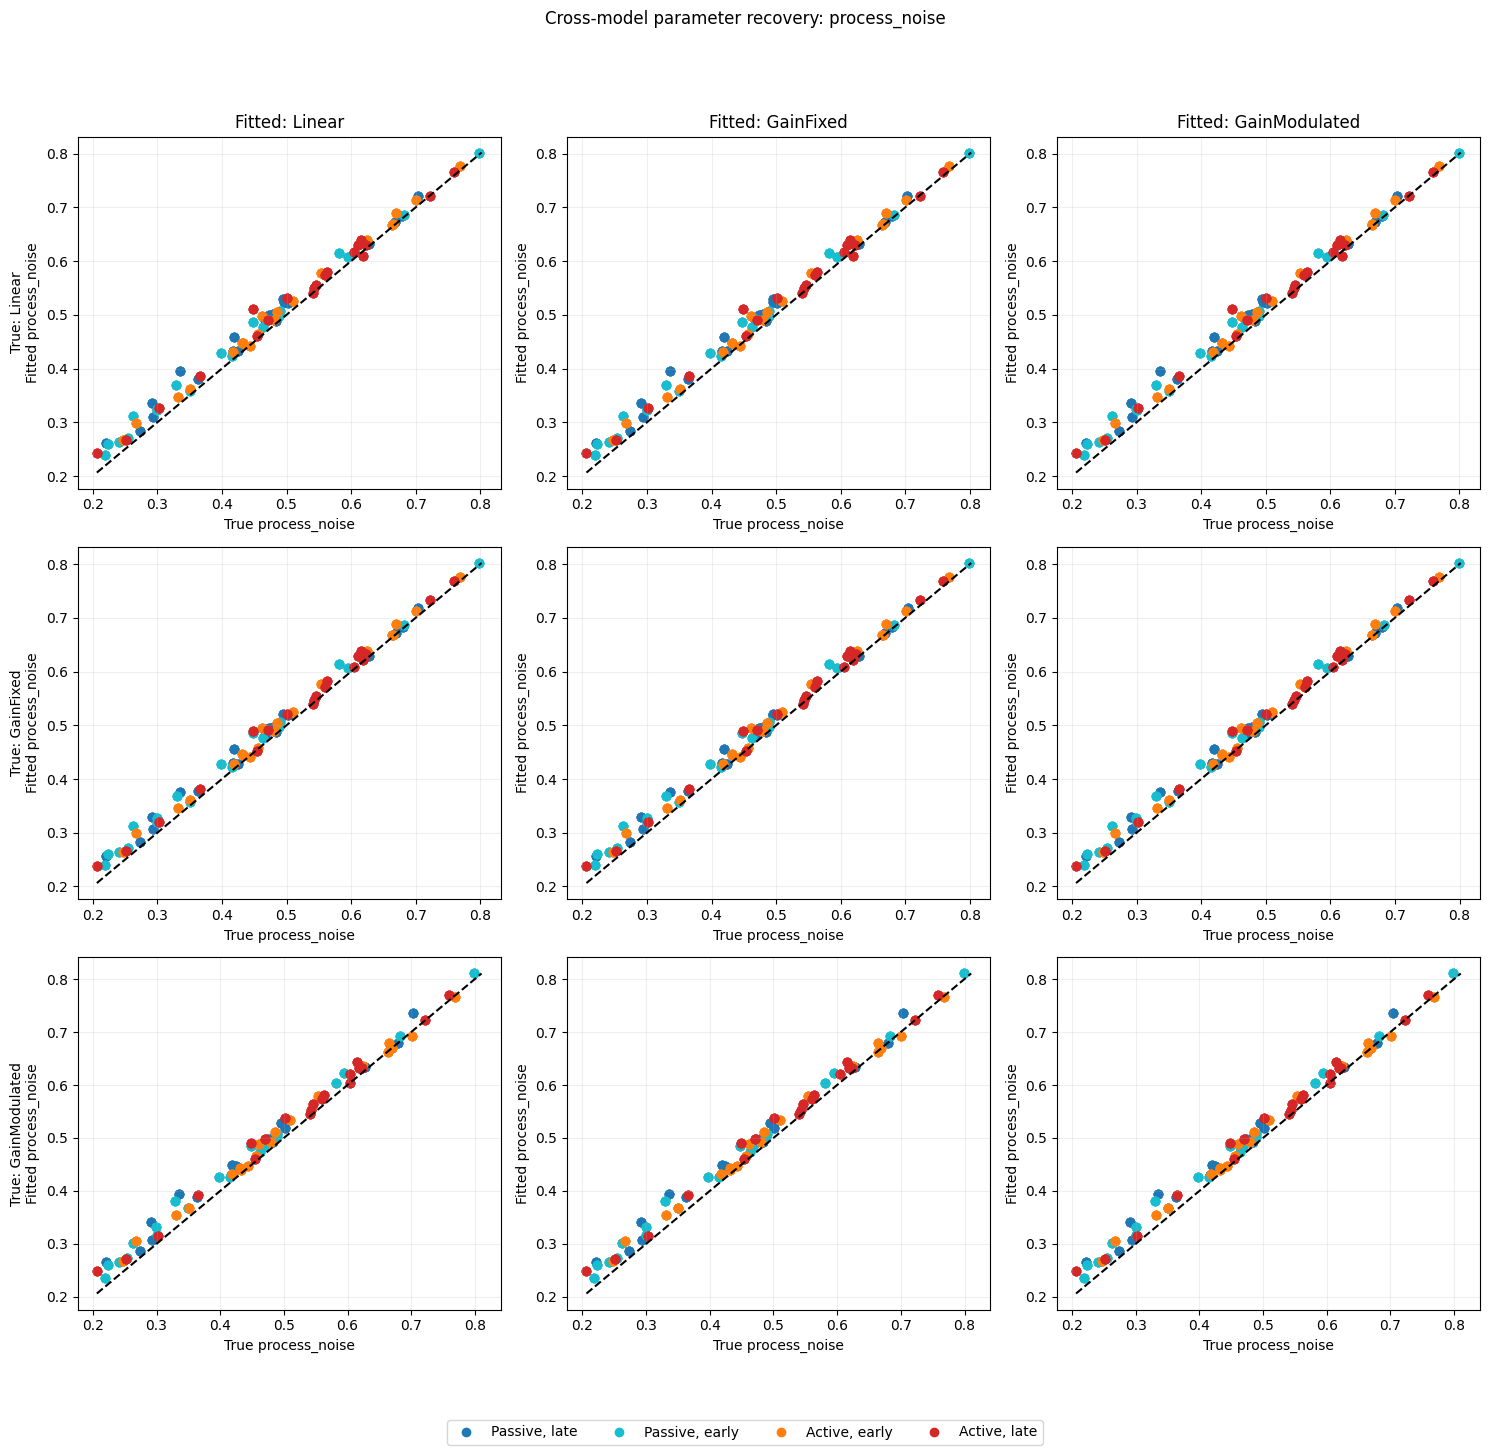

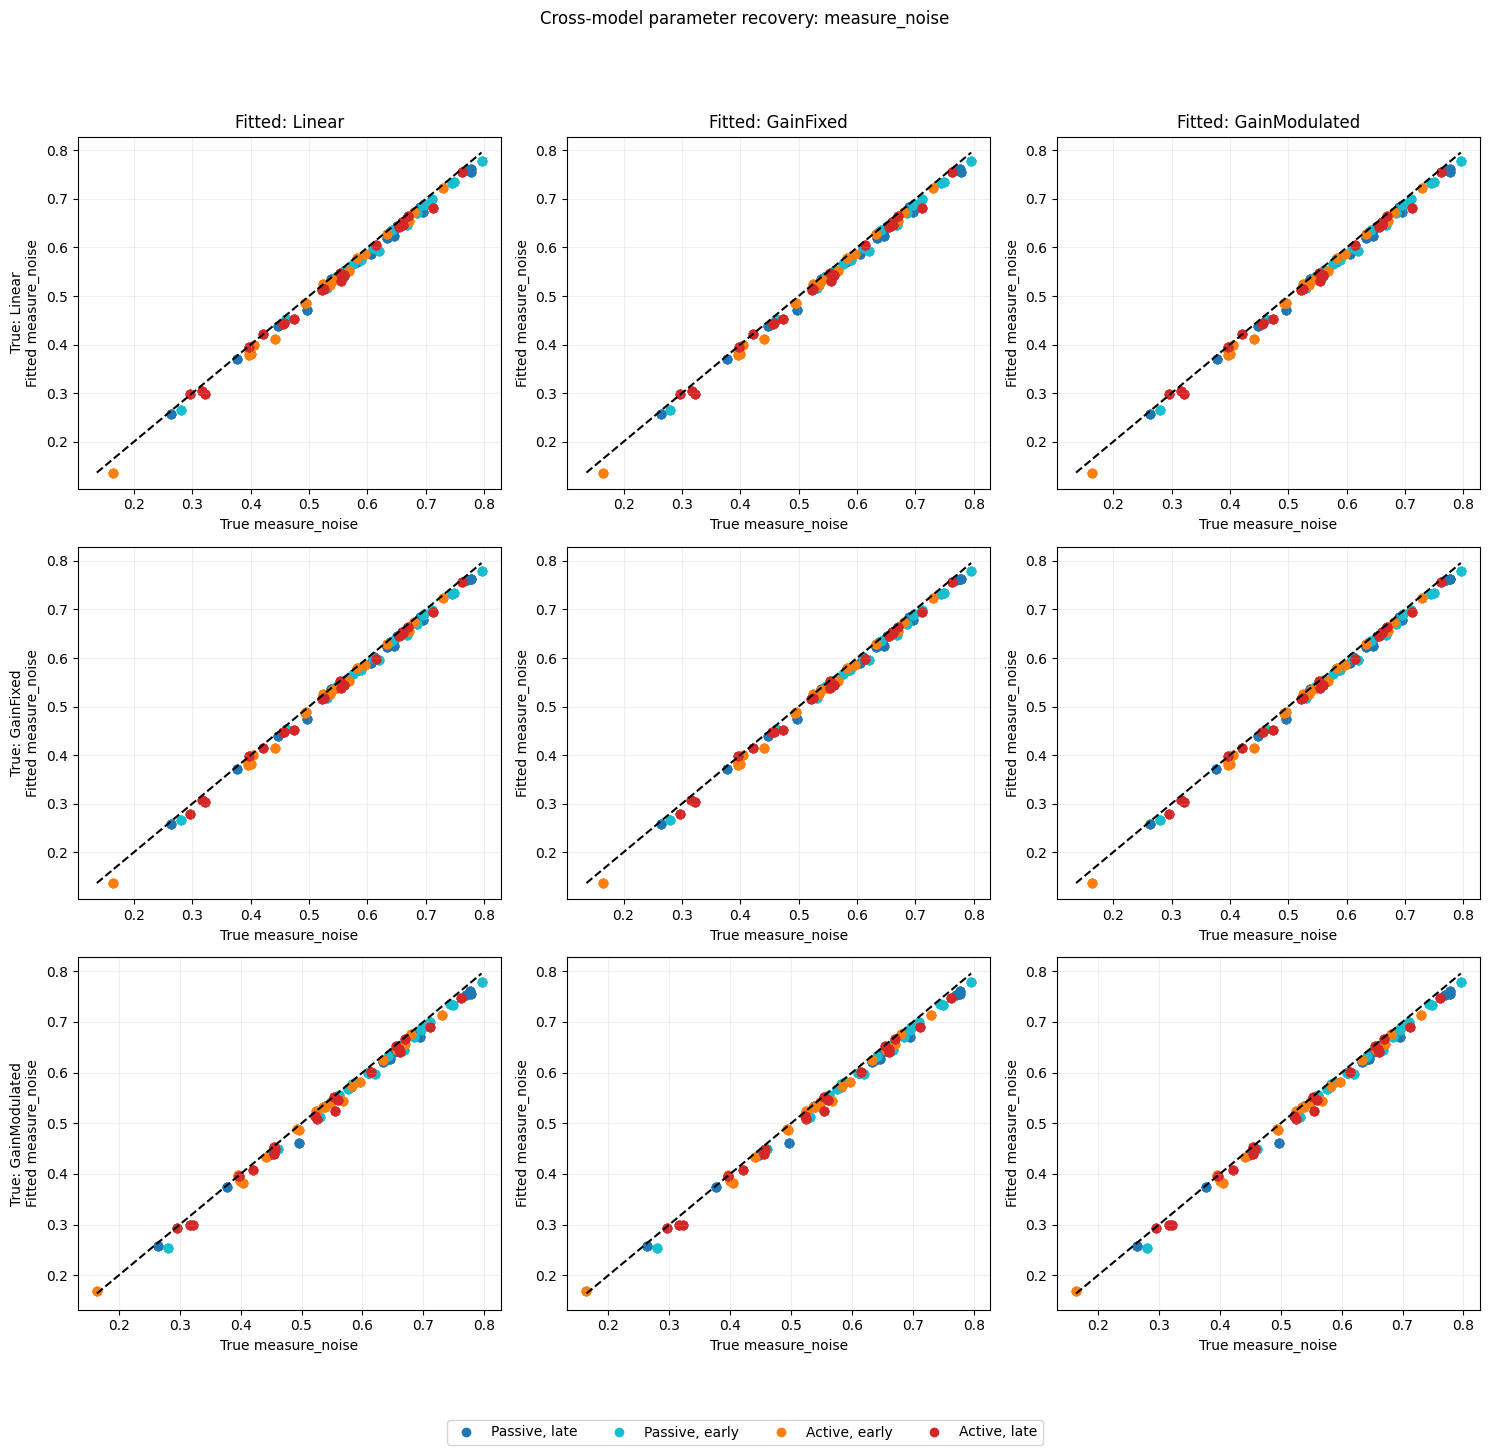

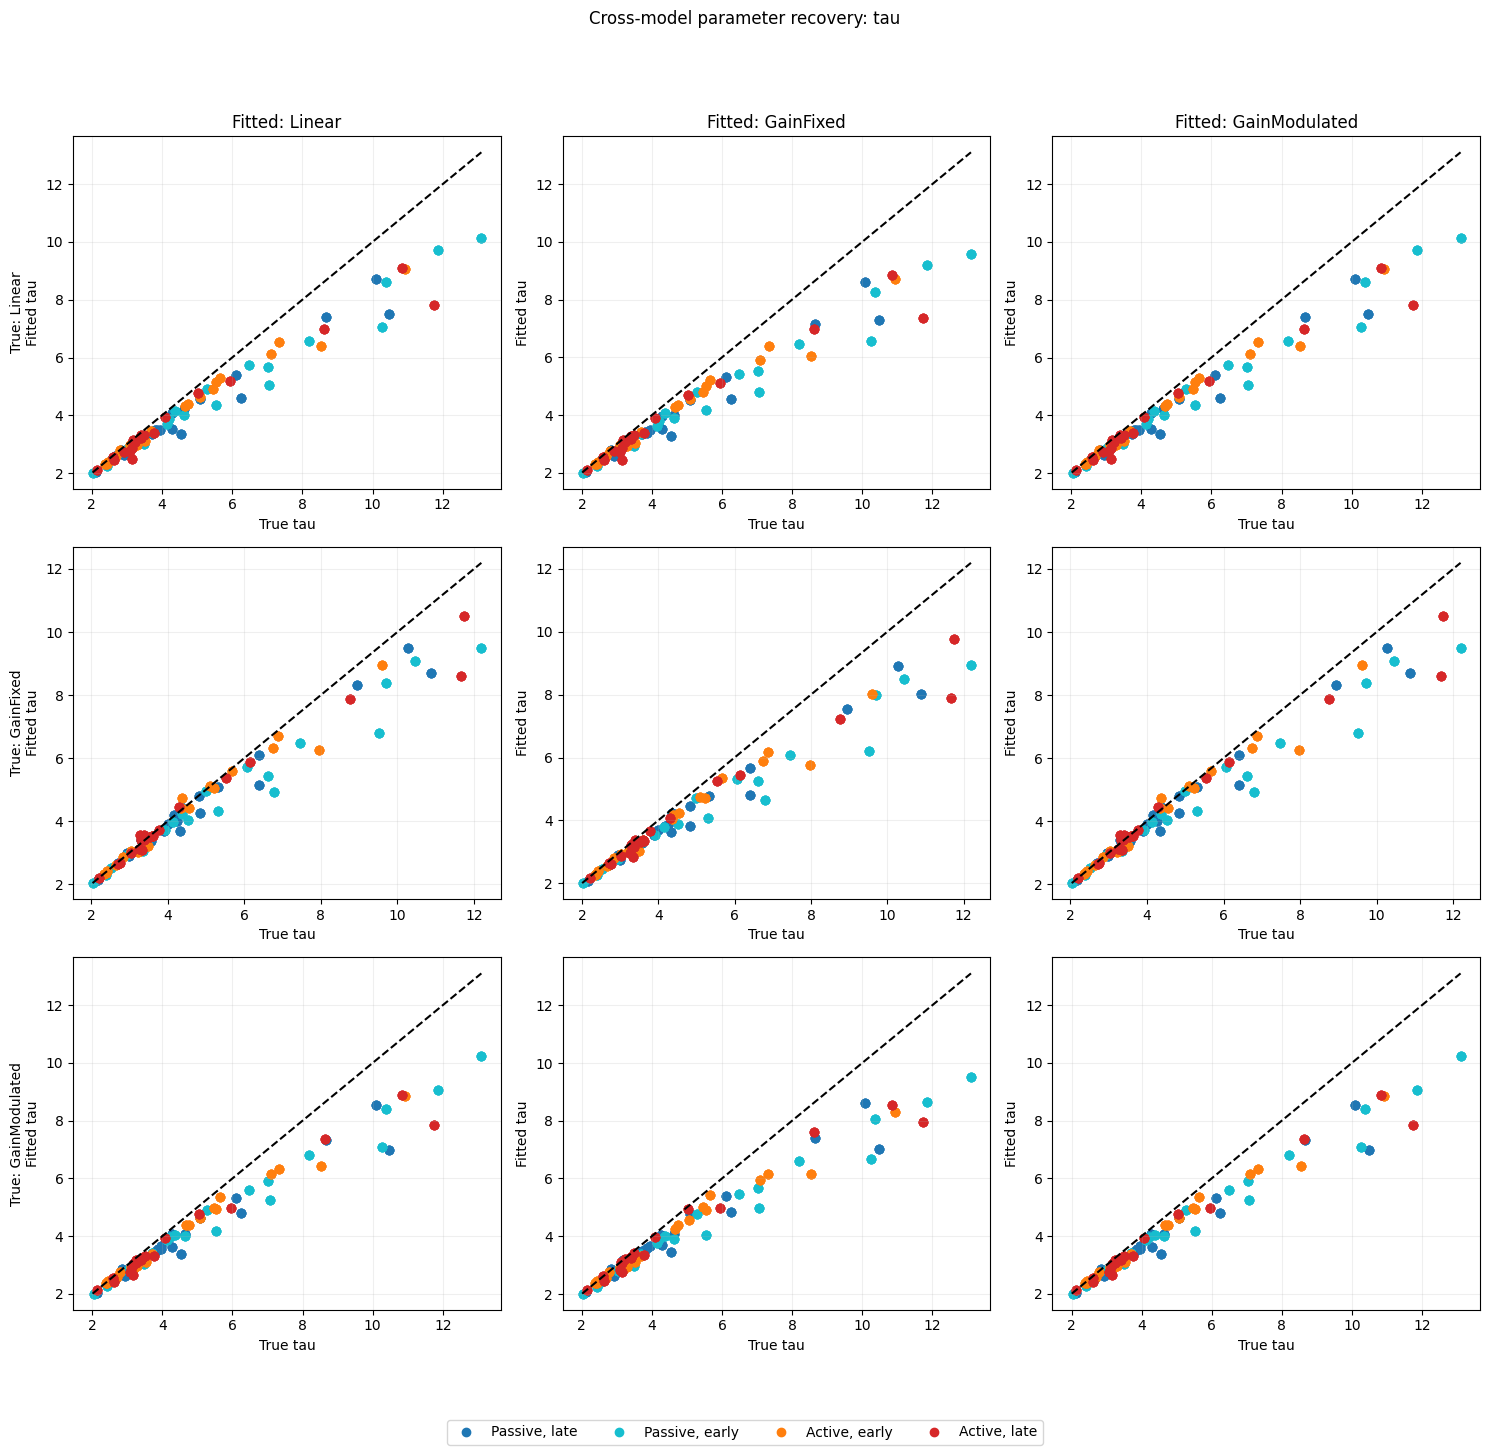

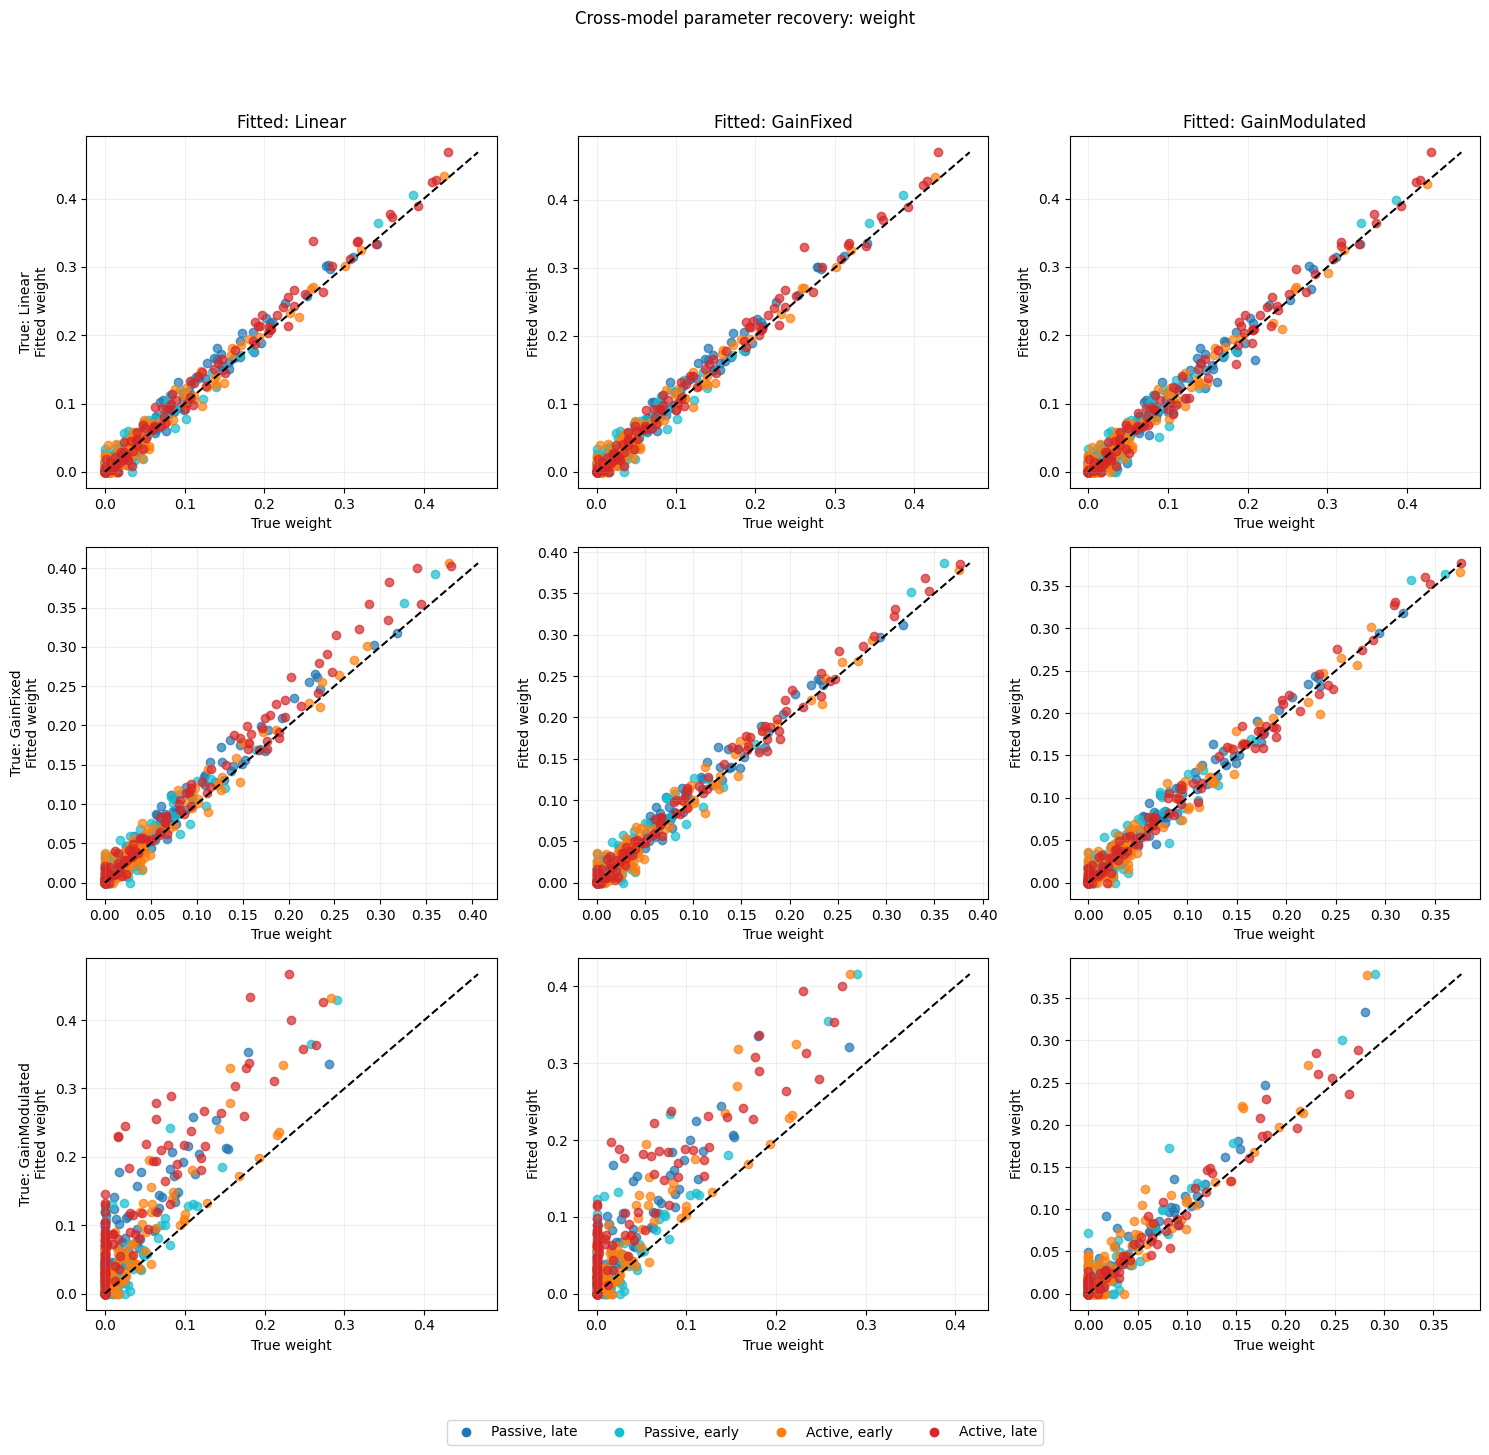

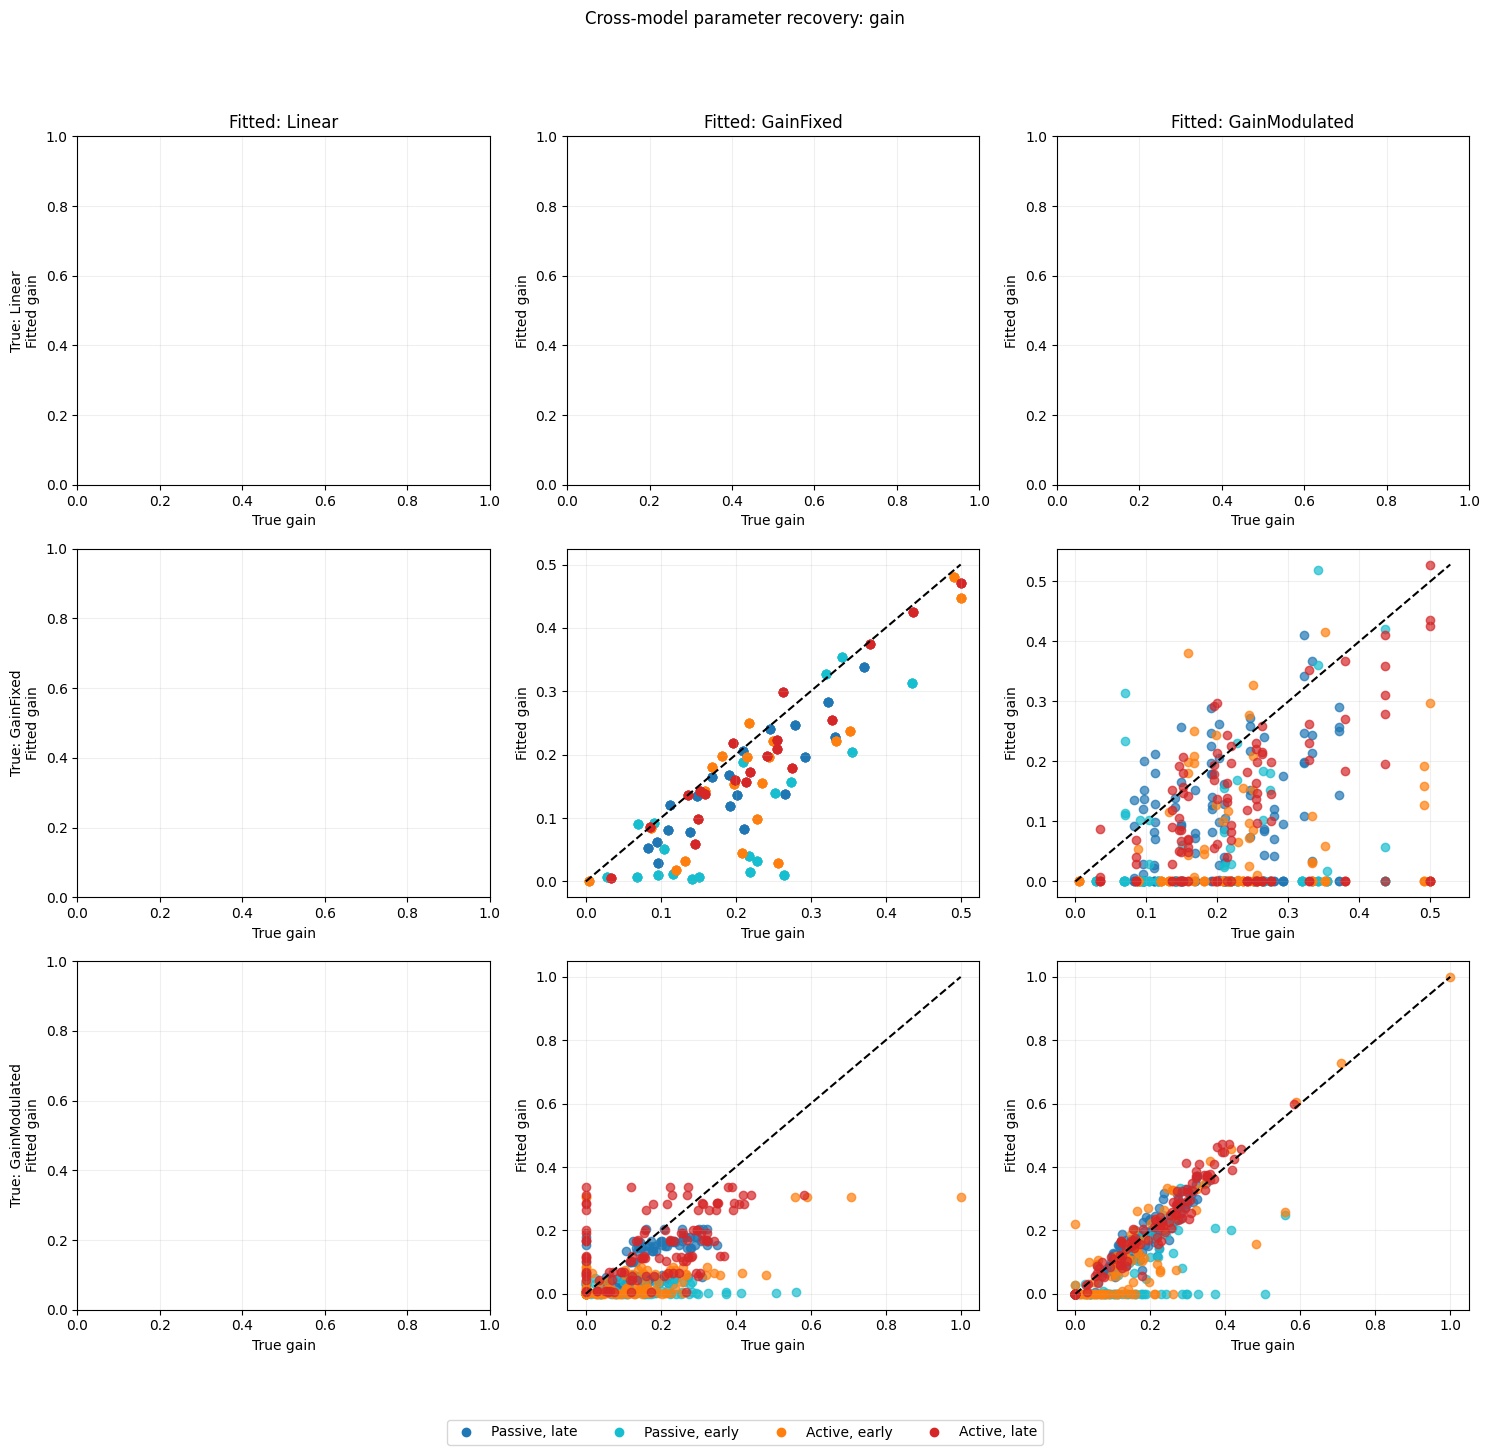

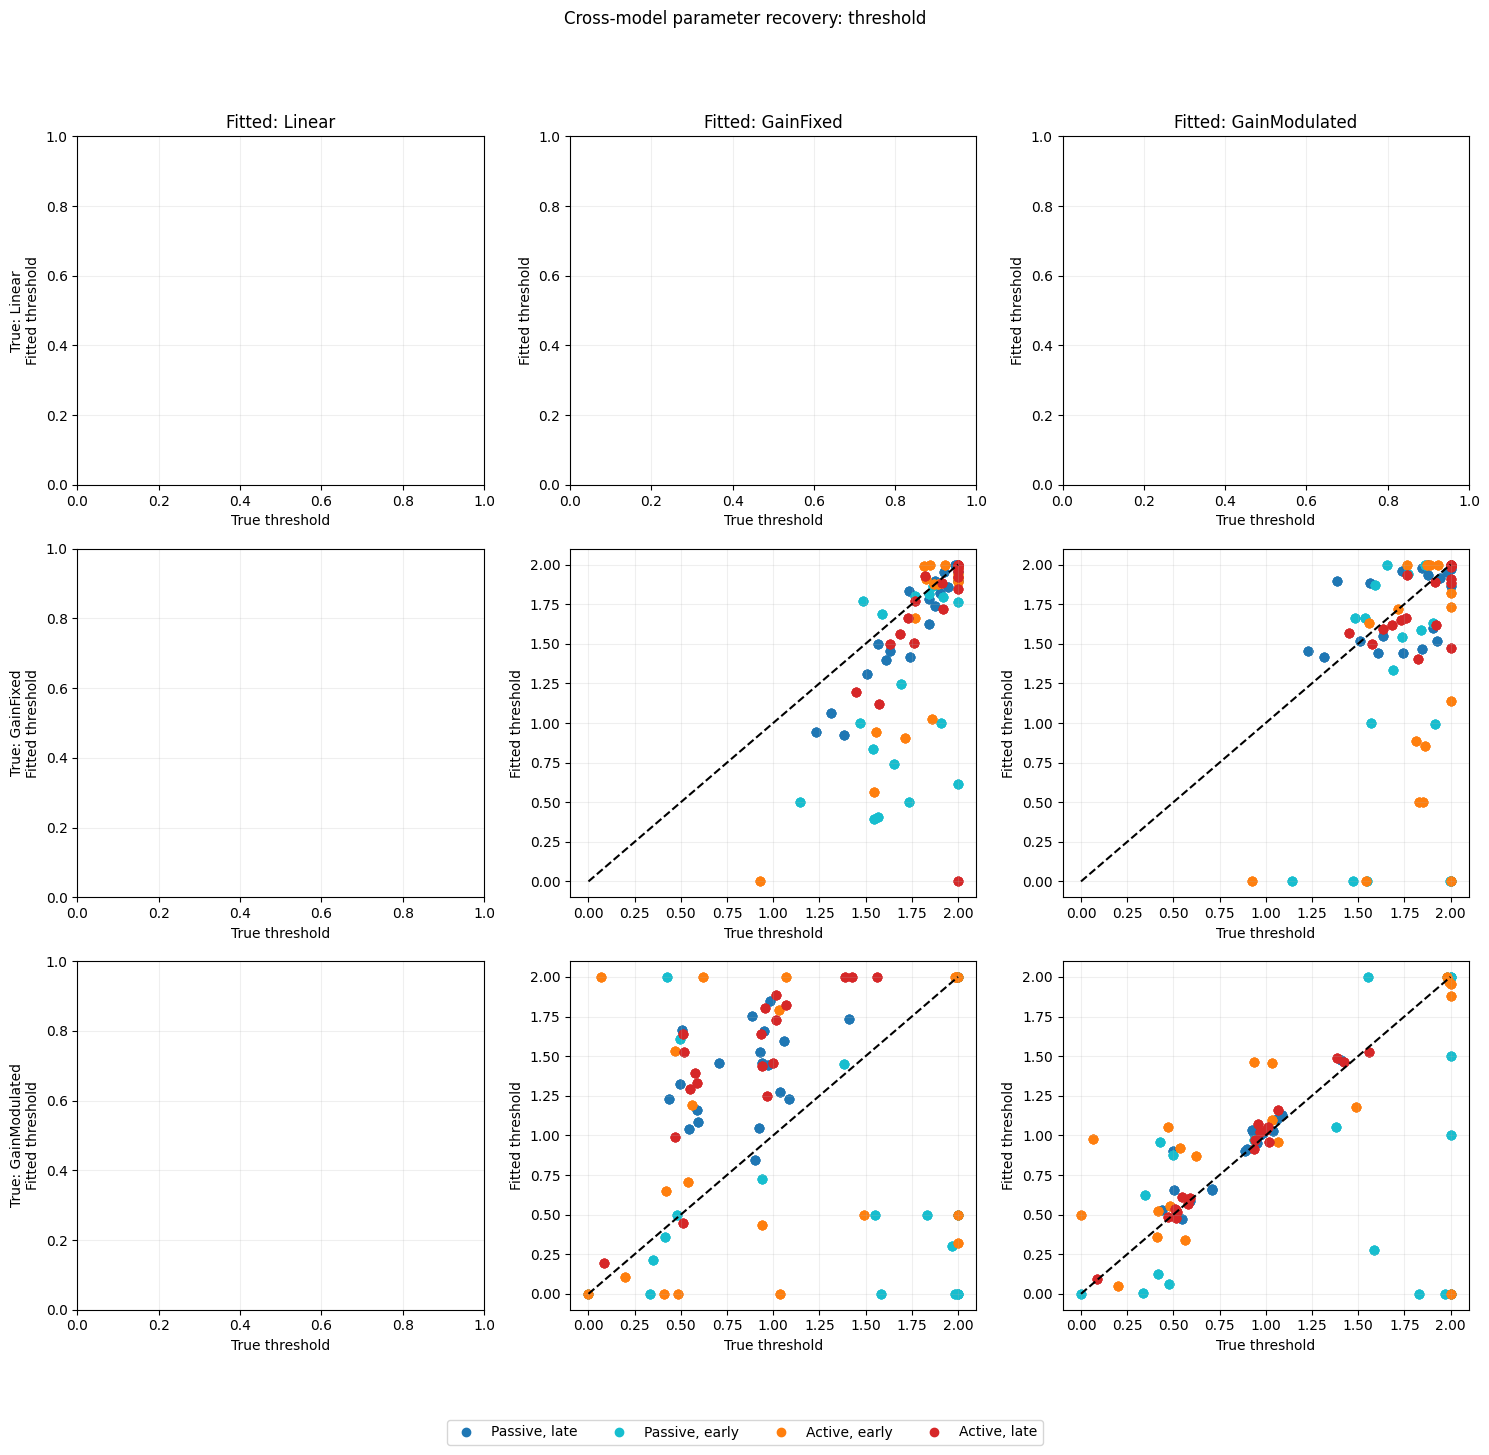

In [8]:
# Cross-model parameter recovery: rows are the true model and columns are the fitted model.
def get_parameter_values(model, model_name, param):
    if param == 'weight':
        return np.asarray([getattr(model, f'w{i}') for i in range(1, 7)], dtype=float)
    if param == 'gain':
        if model_name == 'GainFixed':
            return np.full(6, getattr(model, 'gain'), dtype=float)
        if model_name == 'GainModulated':
            return np.asarray([getattr(model, f'g{i}') for i in range(1, 7)], dtype=float)
        return np.full(6, np.nan)
    if param in {'tau', 'process_noise', 'measure_noise', 'threshold'}:
        if hasattr(model, param):
            return np.full(6, getattr(model, param), dtype=float)
        return np.full(6, np.nan)
    raise ValueError(f'Unsupported parameter: {param}')
for param in parameters:
    fig, axes = plt.subplots(len(models), len(models), figsize=(15, 14), squeeze=False)
    for true_row, (true_name, (true_model_class, _)) in enumerate(models.items()):
        for fitted_col, (fitted_name, (fitted_model_class, fitted_file_name)) in enumerate(models.items()):
            ax = axes[true_row, fitted_col]
            all_true_values, all_fitted_values = [], []
            for task, period, color in conditions:
                true_values, fitted_values = [], []
                folder = Path('ParameterRecovery') / f'{task}_{period}' / f'From_{true_name}'
                for part in range(20):
                    true_path = folder / f'TrueModel_part{part}_params'
                    fitted_path = folder / f'{fitted_file_name}_part{part}_params'
                    if not true_path.exists() or not fitted_path.exists():
                        continue
                    true_kwargs = dict(tau=10, process_noise=0.1, measure_noise=0.1)
                    fitted_kwargs = dict(tau=10, process_noise=0.1, measure_noise=0.1)
                    if true_name != 'Linear':
                        true_kwargs.update(threshold=1, sharpness=5)
                    if fitted_name != 'Linear':
                        fitted_kwargs.update(threshold=1, sharpness=5)
                    if true_name == 'GainFixed':
                        true_kwargs['gain'] = 0.1
                    if fitted_name == 'GainFixed':
                        fitted_kwargs['gain'] = 0.1
                    true_model = true_model_class(**true_kwargs)
                    fitted_model = fitted_model_class(**fitted_kwargs)
                    true_model.load_params(true_path)
                    fitted_model.load_params(fitted_path)
                    true_values.extend(get_parameter_values(true_model, true_name, param))
                    fitted_values.extend(get_parameter_values(fitted_model, fitted_name, param))
                true_arr = np.asarray(true_values, dtype=float)
                fitted_arr = np.asarray(fitted_values, dtype=float)
                valid = np.isfinite(true_arr) & np.isfinite(fitted_arr)
                if valid.any():
                    ax.scatter(
                        true_arr[valid],
                        fitted_arr[valid],
                        color=color,
                        alpha=0.7,
                    )
                    all_true_values.extend(true_arr[valid])
                    all_fitted_values.extend(fitted_arr[valid])
            if all_true_values:
                x_min = np.min(np.r_[all_true_values, all_fitted_values])
                x_max = np.max(np.r_[all_true_values, all_fitted_values])
                if np.isfinite(x_min) and np.isfinite(x_max) and x_max > x_min:
                    ax.plot([x_min, x_max], [x_min, x_max], 'k--')
            if true_row == 0:
                ax.set_title(f'Fitted: {fitted_name}')
            if fitted_col == 0:
                ax.set_ylabel(f'True: {true_name}\nFitted {param}')
            else:
                ax.set_ylabel(f'Fitted {param}')
            ax.set_xlabel(f'True {param}')
            ax.grid(alpha=0.2)
    legend_handles = [
        plt.Line2D([0], [0], marker='o', linestyle='', color=color, label=f'{task}, {period}')
        for task, period, color in conditions
    ]
    fig.suptitle(f'Cross-model parameter recovery: {param}', y=1.02)
    fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.01), ncol=4)
    plt.tight_layout(rect=(0, 0.05, 1, 0.98))
